In [1]:
import re 
import pandas as pd
from collections import Counter


In [2]:
df = pd.read_csv("/Users/kaitaoyang/Downloads/datasets_conversations/DailyDialog/train.csv")
print(df.shape)
df.head(2)

(11118, 3)


,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]


In [3]:
text_raw = " ".join(df.dialog.to_list()).lower()
text_clean_list = re.findall(r"[a-zA-Z\-]+", text_raw)
text_clean_list[:100]

['say',
 'jim',
 'how',
 'about',
 'going',
 'for',
 'a',
 'few',
 'beers',
 'after',
 'dinner',
 'you',
 'know',
 'that',
 'is',
 'tempting',
 'but',
 'is',
 'really',
 'not',
 'good',
 'for',
 'our',
 'fitness',
 'what',
 'do',
 'you',
 'mean',
 'it',
 'will',
 'help',
 'us',
 'to',
 'relax',
 'do',
 'you',
 'really',
 'think',
 'so',
 'i',
 'don',
 't',
 'it',
 'will',
 'just',
 'make',
 'us',
 'fat',
 'and',
 'act',
 'silly',
 'remember',
 'last',
 'time',
 'i',
 'guess',
 'you',
 'are',
 'right',
 'but',
 'what',
 'shall',
 'we',
 'do',
 'i',
 'don',
 't',
 'feel',
 'like',
 'sitting',
 'at',
 'home',
 'i',
 'suggest',
 'a',
 'walk',
 'over',
 'to',
 'the',
 'gym',
 'where',
 'we',
 'can',
 'play',
 'singsong',
 'and',
 'meet',
 'some',
 'of',
 'our',
 'friends',
 'that',
 's',
 'a',
 'good',
 'idea',
 'i',
 'hear',
 'mary',
 'and']

In [4]:
len(set(text_clean_list))

18087

In [5]:
word_counter = Counter(text_clean_list)
word_counter.most_common(1000)


[('i', 45725),
 ('you', 40986),
 ('the', 32365),
 ('to', 27771),
 ('a', 23508),
 ('it', 20392),
 ('s', 15641),
 ('and', 14345),
 ('is', 13811),
 ('that', 13615),
 ('of', 11651),
 ('in', 11116),
 ('have', 10893),
 ('for', 10542),
 ('t', 10458),
 ('do', 9287),
 ('what', 9038),
 ('can', 8528),
 ('are', 8526),
 ('we', 8342),
 ('your', 7899),
 ('my', 7191),
 ('me', 7120),
 ('be', 6480),
 ('this', 6411),
 ('like', 6094),
 ('but', 6031),
 ('on', 6030),
 ('m', 5832),
 ('with', 5312),
 ('yes', 5290),
 ('how', 5212),
 ('so', 5053),
 ('about', 4617),
 ('will', 4612),
 ('there', 4608),
 ('don', 4598),
 ('at', 4239),
 ('ll', 4197),
 ('not', 4077),
 ('think', 4008),
 ('well', 3969),
 ('good', 3888),
 ('no', 3873),
 ('know', 3749),
 ('all', 3676),
 ('get', 3616),
 ('just', 3609),
 ('here', 3604),
 ('would', 3569),
 ('they', 3499),
 ('if', 3428),
 ('go', 3368),
 ('he', 3301),
 ('was', 3270),
 ('see', 3155),
 ('one', 3144),
 ('right', 3115),
 ('very', 3075),
 ('really', 3071),
 ('some', 2956),
 ('want'

In [6]:
# pip install google-cloud-translate
from google.oauth2 import service_account
from google.cloud import translate_v2 as translate

# Load credentials from the JSON file
credentials = service_account.Credentials.from_service_account_file("../kt-languages-148ff3e33c54.json")

# Initialize client
translate_client = translate.Client(credentials=credentials)

# Example usage
result = translate_client.translate("Hello world", target_language="ru")
print(result["translatedText"])




Привет, мир


In [7]:
import argostranslate.package
import argostranslate.translate

# Update model index (list of all available models)
argostranslate.package.update_package_index()
available_packages = argostranslate.package.get_available_packages()

# Find the English → Russian package
package_to_install = next(
    pkg for pkg in available_packages
    if pkg.from_code == "en" and pkg.to_code == "ru"
)

# Install the package
argostranslate.package.install_from_path(package_to_install.download())

# Now load installed languages
installed_languages = argostranslate.translate.get_installed_languages()
from_lang = next(lang for lang in installed_languages if lang.code == "en")
to_lang = next(lang for lang in installed_languages if lang.code == "ru")

translation = from_lang.get_translation(to_lang)

# Test translation
print(translation.translate("Hello world, how are you?"))


/Users/kaitaoyang/Documents/dev/language_learning/.env/lib/python3.12/site-packages/stanza/models/tokenize/trainer.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  check

Привет, мир, как дела?


In [8]:
# Apply row by row
# df["dialog_ru"] = df["dialog"].apply(translation.translate)
# df.to_csv("translated_partial.csv", index=False, encoding="utf-8-sig")

In [9]:
df = pd.read_csv("translated_partial_ru.csv")
text_raw_ru = " ".join(df["dialog_ru"].to_list()).lower()
len(text_raw_ru)

5294035

In [10]:
text_clean_ru_list = re.findall(r"[а-яё\-]+", text_raw_ru)
len(set(text_clean_ru_list))

41297

In [11]:
word_counter_ru = Counter(text_clean_ru_list)
word_counter_ru.most_common(1000)

[('я', 35162),
 ('в', 19696),
 ('это', 18690),
 ('что', 16827),
 ('не', 16507),
 ('вы', 14954),
 ('и', 13501),
 ('на', 10290),
 ('мне', 7615),
 ('ты', 7536),
 ('у', 6990),
 ('с', 6957),
 ('как', 6634),
 ('да', 6498),
 ('мы', 6220),
 ('но', 5871),
 ('бы', 5437),
 ('хорошо', 5080),
 ('есть', 4794),
 ('так', 4746),
 ('для', 4562),
 ('меня', 4537),
 ('о', 4484),
 ('он', 4172),
 ('могу', 3951),
 ('нет', 3845),
 ('чтобы', 3689),
 ('очень', 3689),
 ('все', 3537),
 ('вам', 3536),
 ('ли', 3479),
 ('спасибо', 3389),
 ('вас', 3236),
 ('думаю', 3063),
 ('его', 3061),
 ('если', 3048),
 ('они', 2980),
 ('за', 2790),
 ('пожалуйста', 2478),
 ('когда', 2470),
 ('быть', 2416),
 ('будет', 2413),
 ('просто', 2288),
 ('по', 2274),
 ('тебя', 2237),
 ('можете', 2180),
 ('конечно', 2170),
 ('ну', 2118),
 ('она', 2054),
 ('тебе', 2026),
 ('или', 2019),
 ('много', 1946),
 ('из', 1932),
 ('должны', 1825),
 ('еще', 1819),
 ('сегодня', 1818),
 ('был', 1814),
 ('сделать', 1808),
 ('к', 1793),
 ('было', 1786),
 ('вр

In [12]:
df_words_ru = pd.DataFrame(word_counter_ru.most_common(), columns=["word", "count"])
df_words_ru.sort_values(by="count", ascending=False, inplace=True)
df_words_ru

,word,count
0,я,35162
1,в,19696
2,это,18690
3,что,16827
4,не,16507
...,...,...
30580,кубертен,1
30581,возрождении,1
30582,профессору,1
30583,отсутствовали,1


41297
12693


,root,word,root_rev,nwords
0,ходи,"[происходит, подходит, ходить, приходите, ходи...",идох,117
1,дава,"[давайте, давай, дает, продаются, дают, продае...",авад,107
2,дать,"[дать, дай, дайте, дам, подать, дал, задать, д...",ьтад,98
3,каза,"[сказать, сказал, кажется, рассказать, показат...",азак,97
4,ложи,"[предложить, положить, положите, положил, поло...",ижол,92
...,...,...,...,...
12688,лцена,[полцены],анецл,1
12689,лхаса,[лхаса],асахл,1
12690,лфунт,[полфунта],тнуфл,1
12691,лушатель,[слушателем],ьлеташул,1


<Axes: >

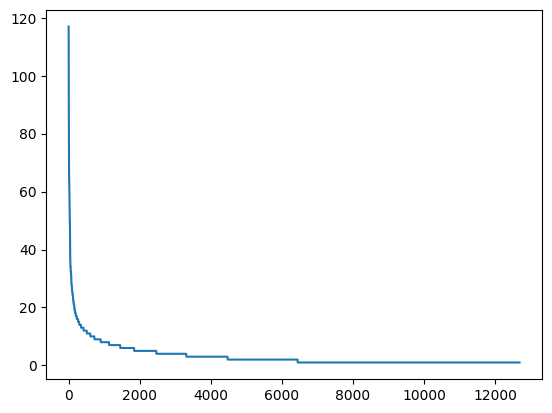

In [24]:
import pymorphy3
import pandas as pd

morph = pymorphy3.MorphAnalyzer()


# Function to remove the first matching prefix
def remove_prefixes(word, prefixes):
    for prefix in prefixes:
        if len(word) - len(prefix) > 3 and word.startswith(prefix):
            return word[len(prefix) :]
    return word


# Function to remove the first matching suffix
def remove_suffixes(word, fixes):
    for f in fixes:
        if len(word) - len(f) > 2 and word.endswith(f):
            return word[: -len(f)]
    return word


# Cache pymorphy3 results to avoid recalculation
morph_cache = {}


def get_normal_form(word):
    if word not in morph_cache:
        morph_cache[word] = morph.parse(word)[0].normal_form
    return morph_cache[word]


# Apply prefix removal and normalization in one pass
prefixes_trash = ["-"]
prefixes_trash += [w.split("-")[0] + "-" for w in df_words_ru.word if "-" in w]
prefixes = [
    "много",
    "видео",
    "после",
    "супер",
    "фото",
    "водо",
    "обез",
    "осве",
    "осво",
    "пере",
    "полу",
    "пред",
    "само",
    "теле",
    "вось",
    "дву",
    "дис",
    "еже",
    "над",
    "под",
    "при",
    "пре",
    "про",
    "раз",
    "рас",
    "без",
    "бес",
    "воз",
    "вос",
    "вне",
    "вс",
    "вз",
    "вы",
    "до",
    "за",
    "им",
    "ин",
    "ис",
    "из",
    "не",
    "об",
    "от",
    "по",
    "со",
    "во",
    "с",
    "у",
    "в",
]
prefixes_sorted = sorted(prefixes, key=lambda x: (-len(x), x))

df_words_ru["word_no_prefix"] = df_words_ru["word"].copy()
for _ in range(1):
    df_words_ru["word_no_prefix"] = df_words_ru["word_no_prefix"].apply(
        lambda x: remove_prefixes(x, prefixes_trash)
    )
    # df_words_ru["word_no_prefix"] = df_words_ru["word_no_prefix"].apply(lambda x: remove_prefixes(x, prefixes))

df_words_ru["root"] = df_words_ru["word_no_prefix"].apply(get_normal_form)

df_words_ru["root"] = df_words_ru["root"].apply(
    lambda x: remove_prefixes(x, prefixes_trash)
)
for _ in range(2):
    df_words_ru["root"] = df_words_ru["root"].apply(
        lambda x: remove_prefixes(x, prefixes)
    )
    df_words_ru["root"] = df_words_ru["root"].apply(
        lambda x: remove_suffixes(x, ["ться", "ть"])
    )


# Group and sort
df_words_ru_root = (
    df_words_ru.groupby("root").agg({"word": list}).reset_index(drop=False)
)

df_words_ru_root["root_rev"] = df_words_ru_root.root.str[::-1]
df_words_ru_root["nwords"] = df_words_ru_root.word.apply(len)
df_words_ru_root = df_words_ru_root.sort_values("nwords", ascending=False).reset_index(
    drop=True
)

df_words_ru_root.to_csv("df_words_ru_root.csv", encoding="utf-8-sig", index=False)
print(df_words_ru.shape[0])
print(df_words_ru_root.shape[0])
display(df_words_ru_root)
df_words_ru_root.nwords.plot()

In [25]:
from itertools import chain


class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.word_indices = []  # store indices of words passing through


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, index):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
            node.count += 1
            node.word_indices.append(index)


def find_longest_prefix_groups(words, min_group_size=2, min_prefix_len=3):
    """
    Iteratively find LONGEST prefixes having >= min_group_size words.
    Optimized: word indices are stored in trie nodes, so we avoid rescanning.
    """
    remaining = list(range(len(words)))  # track indices instead of words
    groups = {}

    while True:
        # Build trie for current remaining indices
        trie = Trie()
        for idx in remaining:
            trie.insert(words[idx], idx)

        new_groups = {}

        def dfs(node, prefix):
            found_child_group = False
            for ch, child in node.children.items():
                if child.count >= min_group_size:
                    dfs(child, prefix + ch)
                    found_child_group = True
            if (
                node.count >= min_group_size
                and not found_child_group
                and len(prefix) >= min_prefix_len
            ):
                new_groups[prefix] = [words[i] for i in node.word_indices]

        dfs(trie.root, "")

        if not new_groups:
            break

        groups.update(new_groups)
        grouped = set(chain.from_iterable(new_groups.values()))
        remaining = [i for i in remaining if words[i] not in grouped]

    singletons = [words[i] for i in remaining]
    return groups, singletons


# Example usage
words = df_words_ru_root.root

prefix_groups, prefix_singletons = find_longest_prefix_groups(
    words, min_group_size=2, min_prefix_len=3
)
prefix_groups = dict(sorted(prefix_groups.items(), key=lambda item: -len(item[1])))


print(len(prefix_groups))
print(len(prefix_singletons))
for sub, words in prefix_groups.items():
    print(sub, words)

print(prefix_singletons)

4446
1629
про ['пробка', 'проход', 'проницаемый', 'прода', 'проща', 'прокат', 'провал', 'промах', 'пролив', 'профи', 'про']
при ['прийти', 'приём', 'пример', 'прибор', 'приход', 'прилёт', 'приезд', 'приют', 'при', 'приимчивый']
род ['роди', 'родный', 'рода', 'родливый', 'роды', 'род', 'родство', 'родригес', 'родковый', 'роде']
пол ['полка', 'полис', 'полёт', 'поле', 'пол', 'полый', 'полюс', 'пола', 'полль', 'поляк']
говор ['говори', 'говор', 'говорный', 'говорящий', 'говоры', 'говорённос', 'говорка', 'говорщик', 'говорчивый']
пере ['пере', 'перейти', 'перерыв', 'переезд', 'перец', 'переход', 'перепад', 'перекус', 'перебой']
тан ['танец', 'танавлива', 'танцующий', 'танок', 'танин', 'танъюань', 'тань', 'танк', 'тан']
тай ['тайский', 'тайный', 'тайванец', 'тайфун', 'тайгера', 'тайчжун', 'тайцзицюань', 'тайаня', 'тай-чи']
тен ['тена', 'тенсивный', 'тение', 'тензия', 'тень', 'теневой', 'тенциал', 'тенка', 'тенг']
ман ['маныва', 'манчивый', 'манка', 'ману', 'манщик', 'маньяк', 'манжета', 'ма

In [15]:
from itertools import chain


class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.word_indices = []  # store indices of words passing through


class Trie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, index):
        node = self.root
        for ch in word:
            if ch not in node.children:
                node.children[ch] = TrieNode()
            node = node.children[ch]
            node.count += 1
            node.word_indices.append(index)


def find_longest_suffix_groups(words, min_group_size=2, min_suffix_len=3):
    """
    Iteratively find LONGEST suffixes having >= min_group_size words.
    Optimized: store word indices at nodes in trie of reversed words.
    """
    remaining = list(range(len(words)))  # indices
    groups = {}

    while True:
        trie = Trie()
        for idx in remaining:
            trie.insert(words[idx][::-1], idx)  # insert reversed word

        new_groups = {}

        def dfs(node, suffix_rev):
            found_child_group = False
            for ch, child in node.children.items():
                if child.count >= min_group_size:
                    dfs(child, suffix_rev + ch)
                    found_child_group = True
            if (
                node.count >= min_group_size
                and not found_child_group
                and len(suffix_rev) >= min_suffix_len
            ):
                suffix = suffix_rev[::-1]  # flip back to original direction
                new_groups[suffix] = [words[i] for i in node.word_indices]

        dfs(trie.root, "")

        if not new_groups:
            break

        groups.update(new_groups)
        grouped = set(chain.from_iterable(new_groups.values()))
        remaining = [i for i in remaining if words[i] not in grouped]

    singletons = [words[i] for i in remaining]
    return groups, singletons

# Example usage
words = df_words_ru_root.root

suffix_groups, suffix_singletons = find_longest_suffix_groups(
    words, min_group_size=2, min_suffix_len=3
)
suffix_groups = dict(sorted(suffix_groups.items(), key=lambda item: -len(item[1])))

# Print results
print(len(suffix_groups))
print(len(suffix_singletons))

print("Shared suffix groups:")
for suffix, group_words in suffix_groups.items():
    print(f"'{suffix}' -> {group_words}")

print("\nSingletons (no shared suffix):")
print(suffix_singletons)


4078
1475
Shared suffix groups:
'лый' -> ['тёплый', 'милый', 'рослый', 'етлый', 'шлый', 'тусклый', 'голый', 'лый', 'ялый', 'ядлый', 'нылый', 'мёрзлый']
'ара' -> ['тара', 'пара', 'ара', 'барбара', 'жара', 'игара', 'еллара', 'кара', 'нара', 'ксара', 'мара']
'ана' -> ['икебана', 'шана', 'сана', 'чанга-ана', 'енчмана', 'дайана', 'ана', 'нирвана', 'нана', 'наана', 'мегана']
'лина' -> ['лина', 'длина', 'циплина', 'шлина', 'миндалина', 'клина', 'чилина', 'эйлина', 'данлина', 'патулина', 'маккуиллина']
'ать' -> ['дать', 'тать', 'ать', 'чать', 'пать', 'кать', 'жать', 'щать', 'мать', 'рать']
'ить' -> ['бить', 'жить', 'чить', 'пить', 'ить', 'лить', 'дить', 'нить', 'шить', 'тить']
'ствова' -> ['чувствова', 'частвова', 'путешествова', 'действова', 'ствова', 'собствова', 'имствова', 'сердствова', 'ершенствова', 'льствова']
'ант' -> ['консультант', 'ант', 'музыкант', 'конкурсант', 'консервант', 'тендант', 'ержант', 'гигант', 'брайант', 'номинант']
'ковый' -> ['одинаковый', 'ковый', 'хлопковый', 'прыж

In [16]:
shared_sigletons = set(prefix_singletons).intersection(set(suffix_singletons))
unshared_sigletons = set(prefix_singletons).union(set(suffix_singletons)) - shared_sigletons
print(len(shared_sigletons))
print(len(unshared_sigletons))
print(shared_sigletons)
print(unshared_sigletons)

503
2055
{'энрике', 'кесадилья', 'хебес', 'ъян', 'мм', 'нло', 'сев', 'ппп', 'йма', 'ют', 'нообразие', 'оуэн', 'ааа', 'по', 'обои', 'тётя', '-за', 'ж', 'обед', 'хифя', 'ыпи', 'де', 'гвинея', 'ох-ох', 'зов', 'эй', 'л', 'биг', 'чёба', 'рфа', 'ээ', 'мие', 'эшли', 'вне', 'тюжи', 'нег', 'сед', 'да', 'лао-ш', 'гуш', 'юнмэя', 'храпе', 'бийца', 'ю', 'жужжа', 'шес', 'зу', 'юда', 'ит', 'тху', 'жюли', 'зле', 'под', 'йна', 'мва', 'дядя', 'юк', 'хех', 'виа', 'оес', 'хлыну', 'бюб', 'кедр', 'шепта', 'ла', 'прыщ', 'нгл', 'зип', '-', 'лтд', 'готч', 'заяц', 'нна', 'ду', 'шайба', 'х', 'дауа', 'льюис', 'плс', 'фаджит', 'до', 'ми', 'астма', 'мл', 'няня', 'чис', 'рыда', 'мо', 'тв', 'ляо', 'сме', 'ан', 'к', 'сэм', 'еул', 'ус', 'иду', 'уже', 'сек', 'ху', 'оксид', 'к-', 'орёл', 'кк', 'г-жа', 'ям', 'ину', 'мп', 'сея', 'чоу', '-го', 'слр', 'кл', 'за', 'кешью', 'нибы', 'ввс', '-е', 'хум', 'из', 'кг', 'имб', 'паб', 'суг', 'м', 'тх', 'шакил', 'меется', 'пётр', 'ждь', 'э', 'ин', 'рка', 'аммо', 'му', 'з', 'егэ', 'аа',

In [17]:
from collections import defaultdict


def find_shared_substrings(words, min_group_size=2, min_length=2):
    """
    Find all substrings that appear in at least `min_group_size` words.
    Only consider substrings of length >= min_length.
    """
    substring_map = defaultdict(set)  # substring -> set of words

    for word in words:
        n = len(word)
        seen = set()  # avoid counting duplicate substrings in the same word
        # Generate all substrings of length >= min_length
        for start in range(n):
            for end in range(start + min_length, n + 1):
                sub = word[start:end]
                if sub not in seen:
                    substring_map[sub].add(word)
                    seen.add(sub)

    # Filter by min_group_size
    result = [
        (sub, list(word_set))
        for sub, word_set in substring_map.items()
        if len(word_set) >= min_group_size
    ]

    # Optionally, sort by substring length (longest first)
    result.sort(key=lambda x: (-len(x[0]), x[0]))
    return result


# Example usage
words = df_words_ru_root.root

shared_subs = find_shared_substrings(words, min_group_size=2, min_length=2)

# Deduplicate shared_subs by group_words, keep longest sub
deduped = {}
for sub, group_words in shared_subs:
    key = tuple(sorted(group_words))  # make group_words hashable
    if key not in deduped or len(sub) > len(deduped[key]):
        deduped[key] = sub

# Rebuild as list of (sub, group_words)
shared_subs_deduped = {sub: list(key) for key, sub in deduped.items()}

print("Before deduplication:", len(shared_subs))
print("After deduplication:", len(shared_subs_deduped))
print("Deduplicated shared substrings:")
for sub, group_words in shared_subs_deduped.items():
    print(f"'{sub}' -> {group_words}")

Before deduplication: 29713
After deduplication: 14607
Deduplicated shared substrings:
'идесятипроцентный' -> ['емидесятипроцентный', 'пятидесятипроцентный']
'конкурентоспособн' -> ['конкурентоспособнос', 'конкурентоспособный']
'десятипроцентный' -> ['десятипроцентный', 'емидесятипроцентный', 'пятидесятипроцентный']
'благотворительн' -> ['благотворительнос', 'благотворительный']
'влетворительный' -> ['влетворительный', 'довлетворительный']
'довлетворительн' -> ['довлетворительно', 'довлетворительный']
'коллекционирова' -> ['коллекционирова', 'коллекционирование']
'континентальный' -> ['континентальный', 'межконтинентальный']
'конфиденциально' -> ['конфиденциально', 'конфиденциальнос']
'адцатиминутный' -> ['двадцатиминутный', 'пятнадцатиминутный']
'вительственный' -> ['кровительственный', 'правительственный']
'влетворительно' -> ['влетворительно', 'довлетворительно']
'кондиционирова' -> ['кондиционирова', 'кондиционирование']
'конфиденциальн' -> ['конфиденциально', 'конфиденциальнос', '

In [18]:
middle_groups = {
    sub: group_words
    for sub, group_words in shared_subs_deduped.items()
    if not group_words[0].startswith(sub) and not group_words[0].endswith(sub) and len(sub)>3
}
print(len(shared_subs_deduped))
print(len(middle_groups))
for sub, group_words in middle_groups.items():
    print(f"'{sub}' -> {group_words}")

14607
3199
'функциональн' -> ['многофункциональный', 'функционально', 'функциональный']
'кологически' -> ['онкологический', 'экологически', 'экологический']
'творительно' -> ['благотворительнос', 'влетворительно', 'довлетворительно']
'авительств' -> ['правительственный', 'правительство', 'тавительство']
'вительство' -> ['кровительствова', 'правительство', 'тавительство']
'ершеннолет' -> ['вершеннолетний', 'ершеннолетие']
'направленн' -> ['нонаправленный', 'целенаправленно']
'национальн' -> ['многонациональный', 'национальнос', 'национальный', 'тернациональный', 'транснациональный', 'щенациональный']
'ографирова' -> ['тенографирование', 'фотографирова', 'фотографирование']
'ологически' -> ['астрологический', 'биологический', 'геологический', 'метеорологический', 'онкологический', 'психологический', 'теологический', 'технологический', 'томатологический', 'физиологический', 'хронологический', 'экологически', 'экологический']
'ообразован' -> ['командообразование', 'кообразованный']
'органи